In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist

In [2]:
stores = sorted(Path("../data/tracks").glob("Parcels_run_*_*.zarr"))
stores

[PosixPath('../data/tracks/Parcels_run_1234_2022-06-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-07-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-08-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-09-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-10-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-11-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-12-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-01-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-02-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-03-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-04-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-05-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-06-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-07-01T00:00:00.

In [3]:
ds_list = [xr.open_zarr(s).assign(stores=s.name) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

<xarray.Dataset> Size: 27GB
Dimensions:     (trajectory: 1900000, obs: 700)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 693 694 695 696 697 698 699
  * trajectory  (trajectory) int64 15MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 5GB dask.array<chunksize=(100000, 700), meta=np.ndarray>
    lon         (trajectory, obs) float32 5GB dask.array<chunksize=(100000, 700), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 11GB dask.array<chunksize=(100000, 700), meta=np.ndarray>
    z           (trajectory, obs) float32 5GB dask.array<chunksize=(100000, 700), meta=np.ndarray>
    stores      (trajectory) <U41 312MB 'Parcels_run_1234_2022-06-01T00:00:00...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [4]:
valid_data = ds.lat.notnull().any('trajectory').compute()
ds=ds.where(valid_data,drop=True)
ds=ds.assign(stores=ds.stores.isel(obs=0))
ds

<xarray.Dataset> Size: 3GB
Dimensions:     (trajectory: 1900000, obs: 76)
Coordinates:
  * obs         (obs) int32 304B 0 1 2 3 4 5 6 7 8 ... 68 69 70 71 72 73 74 75
  * trajectory  (trajectory) int64 15MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 578MB dask.array<chunksize=(100000, 76), meta=np.ndarray>
    lon         (trajectory, obs) float32 578MB dask.array<chunksize=(100000, 76), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 1GB dask.array<chunksize=(100000, 76), meta=np.ndarray>
    z           (trajectory, obs) float32 578MB dask.array<chunksize=(100000, 76), meta=np.ndarray>
    stores      (trajectory) object 15MB 'Parcels_run_1234_2022-06-01T00:00:0...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [5]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

In [6]:
import numpy as np

lat_bins = np.linspace(lat_min,lat_max,30)
lon_bins = np.linspace(lon_min,lon_max,30)

def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [7]:
hist = ds.groupby('stores').apply(calc_hist)

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


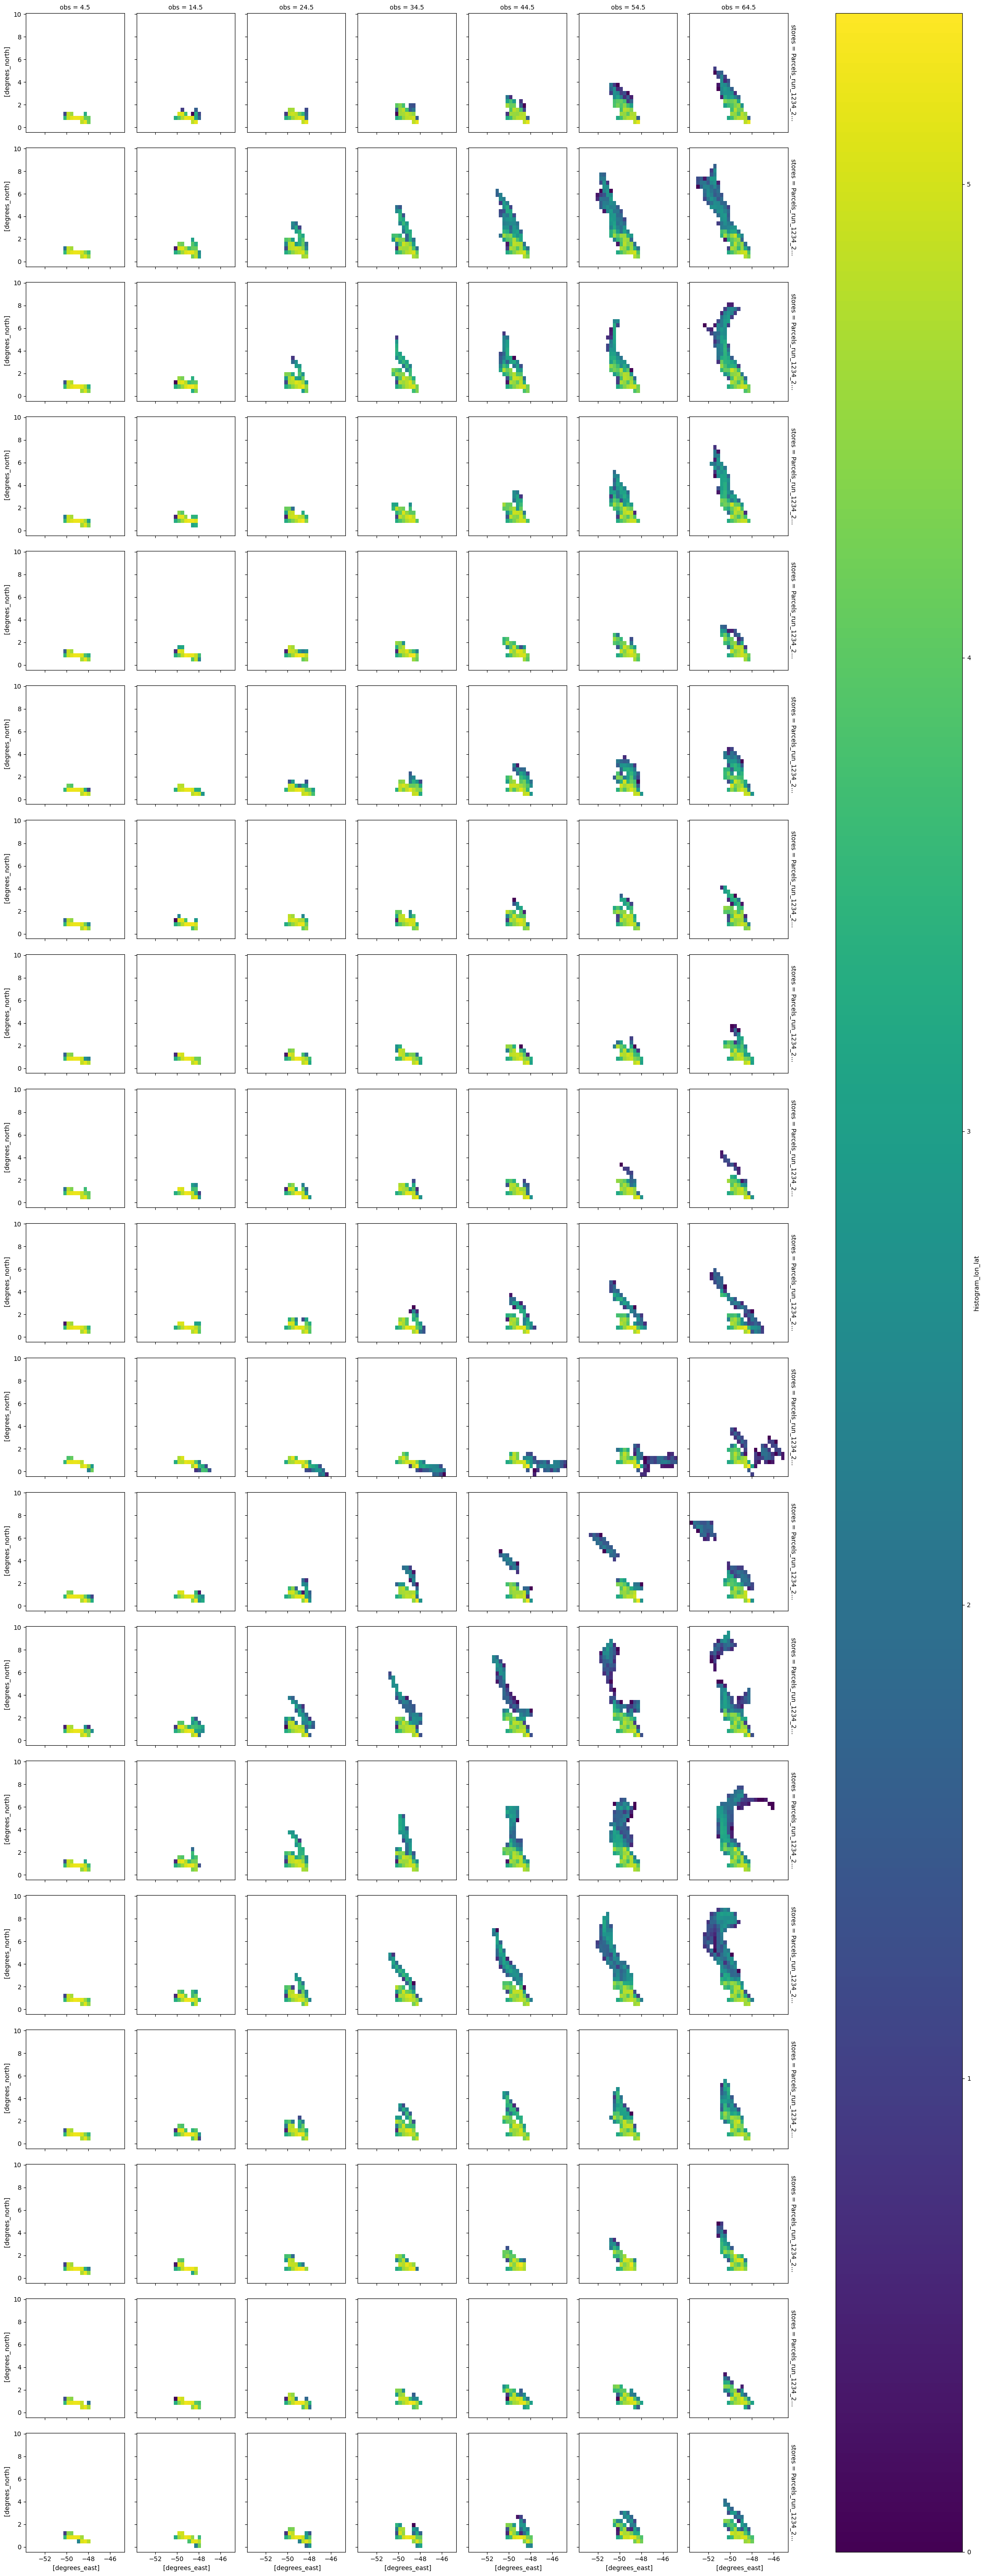

In [12]:
np.log10(hist.coarsen(obs=10,boundary='trim').sum().compute()).plot(
    x='lon',y='lat',
    row='stores',col='obs',
)

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


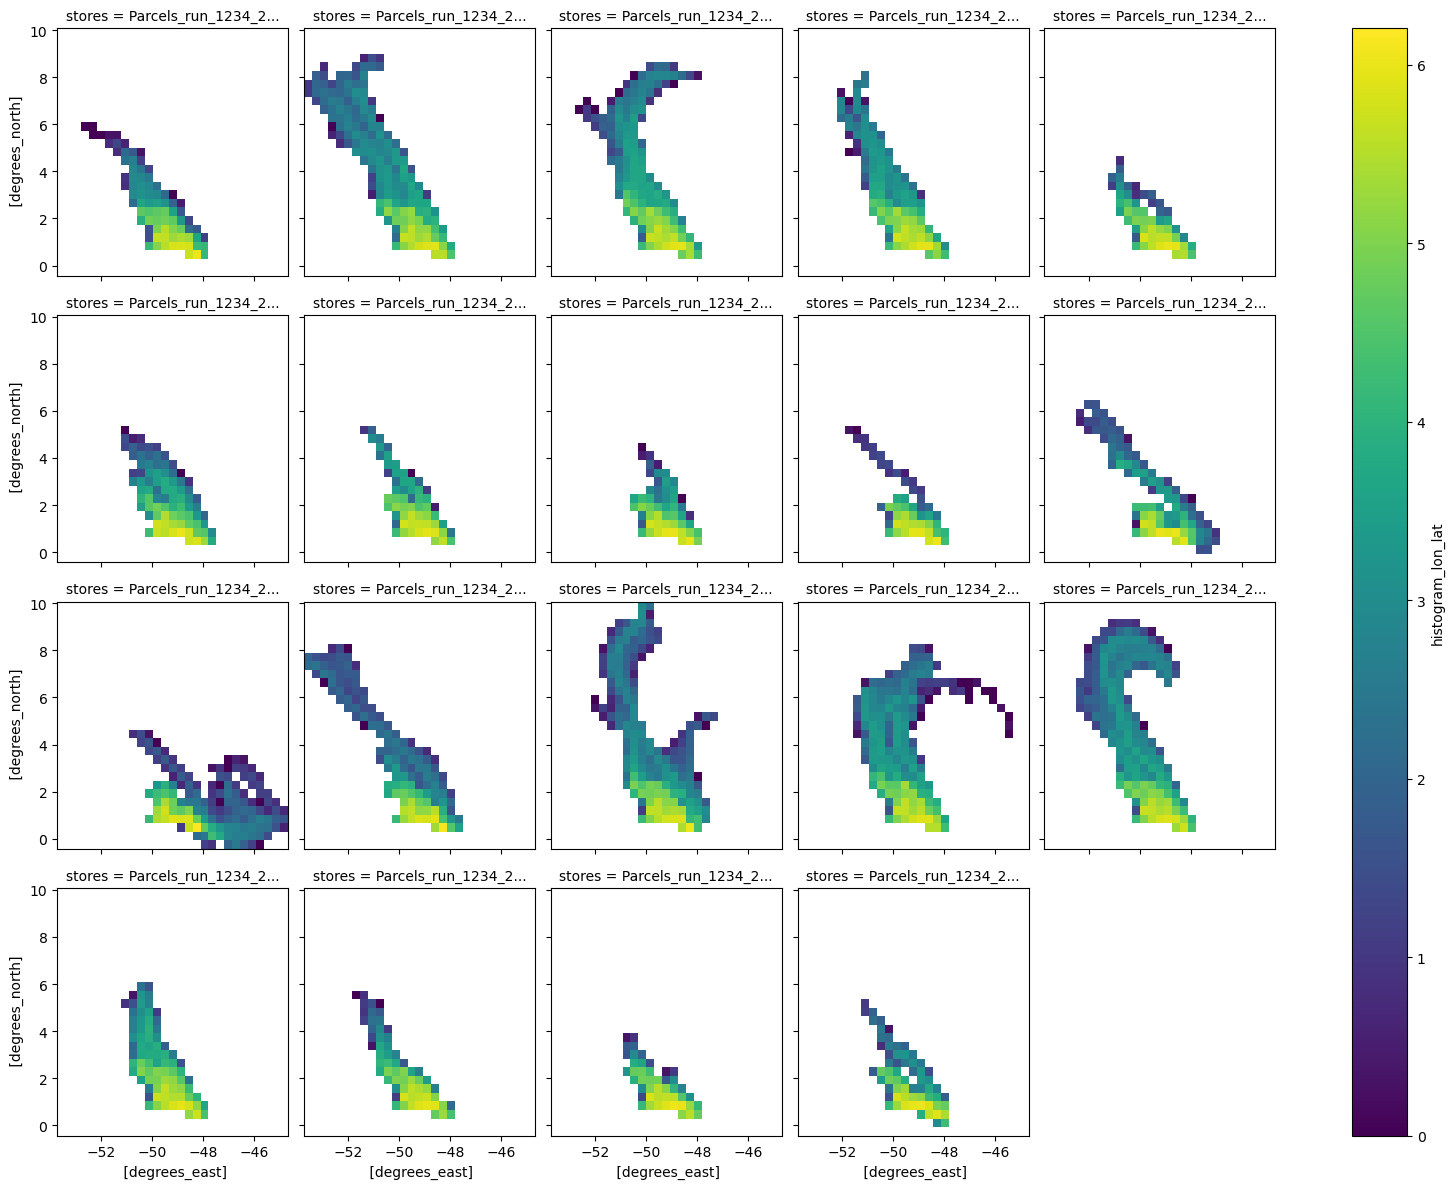

In [13]:
np.log10(hist.sum('obs').compute()).plot(
    x='lon',y='lat',
    col='stores',col_wrap=5,
)